In [17]:
# Install if needed
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib tqdm

import os
import json
import glob
import warnings
import joblib
from pathlib import Path
from datetime import datetime
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("✅ All imports successful")

✅ All imports successful


In [18]:
# ─── USER CONFIG ──────────────────────────────────────────────────────────────
MININDN_DIR = "../Logs"          # Root folder containing node subfolders
MODEL_DIR   = "../Models"           # Where to save trained model artifacts
RESULTS_DIR = "../Results"          # Where to save evaluation plots/CSVs
DATASETS_DIR = "../Datasets"          # Where to save processed datasets (optional)
# Isolation Forest hyperparameters
IF_CONTAMINATION = 0.01   # Expected fraction of anomalies (tune as needed)
IF_N_ESTIMATORS  = 200
IF_MAX_SAMPLES   = 'auto'
IF_RANDOM_STATE  = 42

# Anomaly score threshold (lower = more anomalous in sklearn; -0.1 is typical)
# We use the percentile approach for auto-thresholding after training
# ANOMALY_PERCENTILE = 1   # Bottom 5% of scores flagged as anomalies

# Feature columns produced by feature engineering
FEATURE_COLS = [
    'pit_size', 'pit_growth_rate', 'cs_size', 'cache_hit_ratio',
    'satisfaction_ratio', 'unsatisfied_ratio', 'in_interests_rate',
    'out_interests_rate', 'in_data_rate', 'nack_rate'
]

# Create output directories
for d in [MODEL_DIR, RESULTS_DIR, DATASETS_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"📁 Minindn root : {os.path.abspath(MININDN_DIR)}")
print(f"💾 Model output : {os.path.abspath(MODEL_DIR)}")
print(f"📊 Results dir  : {os.path.abspath(RESULTS_DIR)}")
print(f"📂 Datasets dir : {os.path.abspath(DATASETS_DIR)}")

📁 Minindn root : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Logs
💾 Model output : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Models
📊 Results dir  : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Results
📂 Datasets dir : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Datasets


In [19]:
#Importing all the datasets
normal = pd.read_csv(f"{DATASETS_DIR}/normal_traffic_features.csv")
anomaly = pd.read_csv(f"{DATASETS_DIR}/anomaly_traffic_features.csv")
mixed = pd.read_csv(f"{DATASETS_DIR}/ndn_mixed_normal_anomaly_features.csv")

In [20]:
normal.head()

,timestamp,node,pit_size,pit_growth_rate,cs_size,cache_hit_ratio,satisfaction_ratio,unsatisfied_ratio,in_interests_rate,out_interests_rate,in_data_rate,nack_rate,_scenario,label,class_name,source_scenarios
0,2026-03-13 05:57:22.643020,bottleneck,3.0,0.0,205.0,0.003275,0.997788,0.002212,18.948220,11.758896,11.493717,0.0,logs_dumbbell1,0,normal,logs_dumbbell1
1,2026-03-13 05:57:23.645125,bottleneck,3.0,0.0,205.0,0.003269,0.997788,0.002212,0.000000,0.000000,0.000000,0.0,logs_dumbbell1,0,normal,logs_dumbbell1
2,2026-03-13 05:57:24.656849,bottleneck,3.0,0.0,205.0,0.003262,0.997796,0.002204,18.948220,11.817615,11.493717,0.0,logs_dumbbell1,0,normal,logs_dumbbell1
3,2026-03-13 05:57:25.660706,bottleneck,3.0,0.0,205.0,0.003256,0.997800,0.002200,9.961578,5.976947,6.973105,0.0,logs_dumbbell1,0,normal,logs_dumbbell1
4,2026-03-13 05:57:26.671522,bottleneck,3.0,0.0,205.0,0.003250,0.997804,0.002196,9.892997,5.935798,4.946499,0.0,logs_dumbbell1,0,normal,logs_dumbbell1


In [33]:
#Building model
def build_training_matrix(feat_df: pd.DataFrame) -> np.ndarray:
    """Extract the numeric feature matrix for training."""
    X = feat_df[FEATURE_COLS].values
    print(f"🧮 Training matrix shape: {X.shape}")
    return X


def train_isolation_forest(X: np.ndarray):
    """
    Build a Pipeline:
        StandardScaler  →  IsolationForest
    
    Returns:
        pipeline : fitted sklearn Pipeline
        threshold : float score below which a point is anomalous
    """
    print(f"🌲 Training Isolation Forest (n_estimators={IF_N_ESTIMATORS}, "
          f"contamination={IF_CONTAMINATION}) ...")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('iforest', IsolationForest(
            n_estimators=IF_N_ESTIMATORS,
            contamination=IF_CONTAMINATION,
            max_samples=IF_MAX_SAMPLES,
            random_state=IF_RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    
    pipeline.fit(X)
    print("✅ Training complete.")
    
    # Compute anomaly scores on training data
    scores = pipeline.decision_function(X)   # higher = more normal
    ANOMALY_PERCENTILE = 1  # Flag bottom 0.5% as anomalies (tune as needed)
    
    # Auto-threshold: bottom ANOMALY_PERCENTILE% of normal scores
    threshold = np.percentile(scores, ANOMALY_PERCENTILE)
    print(f"📏 Auto-threshold (p{ANOMALY_PERCENTILE} of training scores): {threshold:.6f}")
    
    return pipeline, threshold, scores

#Splitting the dataset and training the model
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(normal, test_size=0.1, random_state=42)

model = build_training_matrix(X_train)
pipeline, THRESHOLD, train_scores = train_isolation_forest(model)

🧮 Training matrix shape: (113780, 10)
🌲 Training Isolation Forest (n_estimators=200, contamination=0.01) ...
✅ Training complete.
📏 Auto-threshold (p1 of training scores): -0.000000


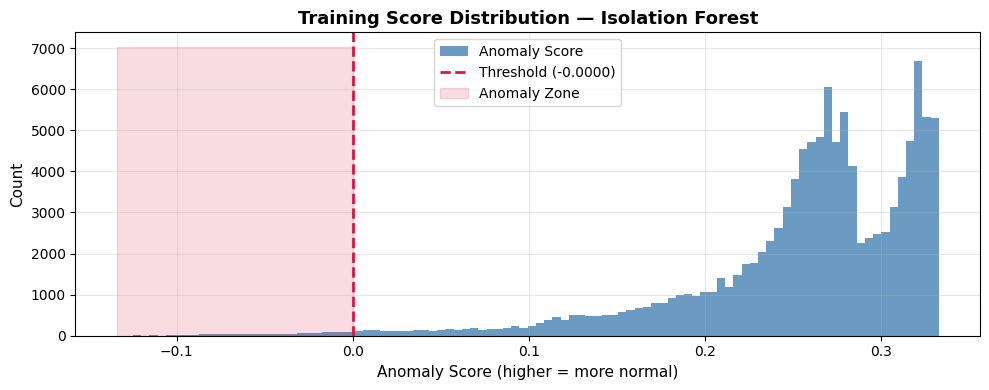

📁 Saved → results/training_score_distribution.png


In [34]:
# ── Training score distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_scores, bins=100, color='steelblue', alpha=0.8, edgecolor='none', label='Anomaly Score')
ax.axvline(THRESHOLD, color='crimson', linewidth=2, linestyle='--', label=f'Threshold ({THRESHOLD:.4f})')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                  train_scores.min(), THRESHOLD,
                  alpha=0.15, color='crimson', label='Anomaly Zone')
ax.set_xlabel('Anomaly Score (higher = more normal)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Training Score Distribution — Isolation Forest', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/training_score_distribution.png")

In [35]:
# ── Per-node score distribution on training data
feat_df_scored = X_train.copy()
feat_df_scored['anomaly_score'] = train_scores
feat_df_scored['is_anomaly']    = (train_scores < THRESHOLD).astype(int)

node_summary = feat_df_scored.groupby('node').agg(
    n_samples   = ('anomaly_score', 'count'),
    mean_score  = ('anomaly_score', 'mean'),
    min_score   = ('anomaly_score', 'min'),
    n_anomalies = ('is_anomaly', 'sum')
).round(4)
node_summary['anomaly_pct'] = (node_summary['n_anomalies'] / node_summary['n_samples'] * 100).round(2)

print("📡 Per-node training score summary:")
display(node_summary)

📡 Per-node training score summary:


,n_samples,mean_score,min_score,n_anomalies,anomaly_pct
node,,,,,
bottleneck,4800,0.2402,0.0294,0,0.00
c1,10369,0.2607,-0.1007,88,0.85
c2,10427,0.2644,-0.1048,76,0.73
c3,10395,0.2662,-0.0894,46,0.44
c4,5079,0.2977,-0.0341,27,0.53
c5,5112,0.2983,-0.0339,28,0.55
c6,5112,0.2989,-0.0341,27,0.53
p1,10385,0.2658,-0.1100,31,0.30
p2,10380,0.2697,-0.0868,29,0.28


In [36]:
# Checking model performance on the test set (normal samples)
X_test_matrix = build_training_matrix(X_test)
test_scores = pipeline.decision_function(X_test_matrix)
test_preds = (test_scores < THRESHOLD).astype(int)
print("\n📊 Test set performance (normal samples only):"
      f"\n- Total samples: {len(X_test)}"
      f"\n- Anomalies detected: {test_preds.sum()} (should be close to 0)"
      f"\n- Normal samples: {len(X_test) - test_preds.sum()} (should be close to total)"
      )

🧮 Training matrix shape: (12643, 10)

📊 Test set performance (normal samples only):
- Total samples: 12643
- Anomalies detected: 119 (should be close to 0)
- Normal samples: 12524 (should be close to total)


In [37]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

# -----------------------------
# 1) Build eval set: ~1% anomaly, ~99% normal
# -----------------------------
SEED = 42
ANOMALY_RATIO = 0.01
N_EVAL = 50000  # change if you want smaller/larger eval set

# Ensure label exists
if "label" not in mixed.columns:
    if "class_name" in mixed.columns:
        mixed["label"] = (mixed["class_name"].astype(str).str.lower() == "anomaly").astype(int)
    else:
        raise ValueError("No 'label' or 'class_name' found in mixed dataset.")

normal_df = mixed[mixed["label"] == 0].copy()
anomaly_df = mixed[mixed["label"] == 1].copy()

n_anom = int(N_EVAL * ANOMALY_RATIO)
n_norm = N_EVAL - n_anom

# Cap by available rows
n_anom = min(n_anom, len(anomaly_df))
n_norm = min(n_norm, len(normal_df))

eval_df = pd.concat([
    anomaly_df.sample(n=n_anom, random_state=SEED, replace=False),
    normal_df.sample(n=n_norm, random_state=SEED, replace=False)
], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print(f"Eval size: {len(eval_df):,}")
print(eval_df["label"].value_counts(normalize=True).rename("ratio").round(4))
print(eval_df["label"].value_counts().rename("count"))

# -----------------------------
# 2) Predict using prebuilt model
# -----------------------------
# Reuse whichever objects already exist in your notebook
model = loaded_pipeline if "loaded_pipeline" in globals() else pipeline
threshold = loaded_threshold if "loaded_threshold" in globals() else THRESHOLD
feat_cols = loaded_feat_cols if "loaded_feat_cols" in globals() else FEATURE_COLS

X_eval = eval_df[feat_cols].values
scores = model.decision_function(X_eval)              # higher = more normal
y_pred = (scores < threshold).astype(int)             # 1 = anomaly
y_true = eval_df["label"].values

# -----------------------------
# 3) Metrics (dataset label)
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn + 1e-12)
fnr = fn / (fn + tp + 1e-12)

print("\n=== Evaluation vs dataset label ===")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(f"FPR      : {fpr:.4f}")
print(f"FNR      : {fnr:.4f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=["normal", "anomaly"], zero_division=0))

# -----------------------------
# 4) Optional: "attacker-node" ground-truth view for analysis
#    logs_tree_cp  -> p2 attacker
#    logs_dumbbell_ifa -> c1 attacker
# -----------------------------
if {"source_scenarios", "node"}.issubset(eval_df.columns):
    y_true_attacker_node = (
        ((eval_df["source_scenarios"] == "logs_tree_cp") & (eval_df["node"] == "p2")) |
        ((eval_df["source_scenarios"] == "logs_dumbbell_ifa") & (eval_df["node"] == "c1"))
    ).astype(int).values

    cm2 = confusion_matrix(y_true_attacker_node, y_pred, labels=[0, 1])
    tn2, fp2, fn2, tp2 = cm2.ravel()

    print("\n=== Evaluation vs attacker-node label (analysis only) ===")
    print("Confusion matrix [[TN, FP], [FN, TP]]:")
    print(cm2)
    print(f"Precision: {precision_score(y_true_attacker_node, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true_attacker_node, y_pred, zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_true_attacker_node, y_pred, zero_division=0):.4f}")

Eval size: 50,000
label
0    0.99
1    0.01
Name: ratio, dtype: float64
label
0    49500
1      500
Name: count, dtype: int64

=== Evaluation vs dataset label ===
Confusion matrix [[TN, FP], [FN, TP]]:
[[49022   478]
 [  496     4]]
Precision: 0.0083
Recall   : 0.0080
F1       : 0.0081
FPR      : 0.0097
FNR      : 0.9920

Classification report:
              precision    recall  f1-score   support

      normal       0.99      0.99      0.99     49500
     anomaly       0.01      0.01      0.01       500

    accuracy                           0.98     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.98      0.98      0.98     50000


=== Evaluation vs attacker-node label (analysis only) ===
Confusion matrix [[TN, FP], [FN, TP]]:
[[49469   482]
 [   49     0]]
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000


In [38]:
# ── Per-node score distribution on mixed data
mixed_scored = mixed.copy()

# Use available model/threshold from notebook state
model = loaded_pipeline if "loaded_pipeline" in globals() else pipeline
threshold = (
    THRESHOLD_TUNED if "THRESHOLD_TUNED" in globals()
    else (loaded_threshold if "loaded_threshold" in globals() else THRESHOLD)
)
feat_cols = loaded_feat_cols if "loaded_feat_cols" in globals() else FEATURE_COLS

X_mixed = mixed_scored[feat_cols].values
mixed_scores = model.decision_function(X_mixed)

mixed_scored['anomaly_score'] = mixed_scores
mixed_scored['is_anomaly'] = (mixed_scores < threshold).astype(int)

node_summary_mixed = mixed_scored.groupby('node').agg(
    n_samples   = ('anomaly_score', 'count'),
    mean_score  = ('anomaly_score', 'mean'),
    min_score   = ('anomaly_score', 'min'),
    n_anomalies = ('is_anomaly', 'sum'),
).round(4)
node_summary_mixed['anomaly_pct'] = (
    node_summary_mixed['n_anomalies'] / node_summary_mixed['n_samples'] * 100
).round(2)

print("📡 Per-node score summary on MIXED dataset:")
display(node_summary_mixed.sort_values('anomaly_pct', ascending=False))

📡 Per-node score summary on MIXED dataset:


,n_samples,mean_score,min_score,n_anomalies,anomaly_pct
node,,,,,
r1,14671,0.2236,-0.1341,8581,58.49
r3,14660,0.2314,-0.1339,7370,50.27
r2,14667,0.2434,-0.1261,5590,38.11
r4,14658,0.2452,-0.1219,5228,35.67
bottleneck,7113,0.2538,0.0294,2313,32.52
c1,14673,0.2636,-0.1007,4149,28.28
c2,14666,0.2689,-0.1048,3440,23.46
c3,14673,0.2692,-0.0894,3393,23.12
p1,14667,0.2717,-0.1100,3200,21.82


In [40]:
# ── Per-node score distribution on ANOMALY dataset
anomaly_scored = anomaly.copy()

# Use available model/threshold from notebook state
model = loaded_pipeline if "loaded_pipeline" in globals() else pipeline
threshold = (
    THRESHOLD_TUNED if "THRESHOLD_TUNED" in globals()
    else (loaded_threshold if "loaded_threshold" in globals() else THRESHOLD)
)
feat_cols = loaded_feat_cols if "loaded_feat_cols" in globals() else FEATURE_COLS

# Score + predict
X_anom = anomaly_scored[feat_cols].values
anomaly_scores = model.decision_function(X_anom)
anomaly_scored["anomaly_score"] = anomaly_scores
anomaly_scored["is_anomaly"] = (anomaly_scores < threshold).astype(int)

# Same tabular summary format
node_summary_anomaly = anomaly_scored.groupby("node").agg(
    n_samples   = ("anomaly_score", "count"),
    mean_score  = ("anomaly_score", "mean"),
    min_score   = ("anomaly_score", "min"),
    n_anomalies = ("is_anomaly", "sum")
).round(4)

node_summary_anomaly["anomaly_pct"] = (
    node_summary_anomaly["n_anomalies"] / node_summary_anomaly["n_samples"] * 100
).round(2)

print("📡 Per-node score summary on ANOMALY dataset:")
display(node_summary_anomaly.sort_values("anomaly_pct", ascending=False))


📡 Per-node score summary on ANOMALY dataset:


,n_samples,mean_score,min_score,n_anomalies,anomaly_pct
node,,,,,
r3,3106,0.2554,-0.1121,954,30.71
r1,3109,0.2601,-0.1051,915,29.43
r4,3105,0.2655,-0.1105,760,24.48
r2,3109,0.2696,-0.1154,697,22.42
c1,3110,0.2741,-0.0791,694,22.32
c3,3109,0.2811,-0.0532,492,15.83
c2,3110,0.2847,-0.0760,490,15.76
bottleneck,1757,0.2958,0.1234,162,9.22
c5,1054,0.2960,0.1108,89,8.44


** Optimization is still left **